<a href="https://colab.research.google.com/github/Alltingzrpozz/Alltingzrpozz/blob/main/Time_Series_Prediction_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from graphviz import Digraph
from IPython.display import display, Image

# Data Loading and Timeline standardisation

In [2]:
print("--- 2. Data Loading & Timeline Standardisation ---")
# Load dataset and parse the timestamp into a datetime object
df = pd.read_csv('/content/sample_data/PT_Train.csv')
df['Timestamp (GMT)'] = pd.to_datetime(df['Timestamp (GMT)'], format='%d/%m/%Y %H:%M')

# Set the timeline as the index so the algorithms recognize the chronological order
df.set_index('Timestamp (GMT)', inplace=True)
df = df.sort_index()

target_col = 'Lifetouch Heart Rate'

# SANITY CHECK: Display the structure and the first 5 rows
print("\nDataset Structure:")
df.info()
print("\nSample of Loaded Data (First 5 Rows):")
display(df.head())

--- 2. Data Loading & Timeline Standardisation ---

Dataset Structure:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 226 entries, 2015-08-17 15:09:00 to 2015-08-17 18:54:00
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Lifetouch Heart Rate        226 non-null    int64  
 1   Lifetouch Respiration Rate  226 non-null    int64  
 2   Oximeter SpO2               191 non-null    float64
 3   Oximeter Pulse              191 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 8.8 KB

Sample of Loaded Data (First 5 Rows):


,Lifetouch Heart Rate,Lifetouch Respiration Rate,Oximeter SpO2,Oximeter Pulse
Timestamp (GMT),,,,
2015-08-17 15:09:00,139,41,NaN,NaN
2015-08-17 15:10:00,144,40,92.0,140.0
2015-08-17 15:11:00,140,42,89.0,144.0
2015-08-17 15:12:00,138,45,93.0,141.0
2015-08-17 15:13:00,133,42,94.0,134.0


# Data Cleaning & Pre-processing

In [3]:
print("\n--- 3. Data Cleaning & Pre-processing ---")
# Apply a 3-minute rolling average to smooth micro-fluctuations in the sensor data
df['Smoothed_HR'] = df[target_col].rolling(window=3, min_periods=1).mean()

# SANITY CHECK: Compare the raw heart rate against your new smoothed feature
print("Data smoothing complete. Comparing Raw vs. Smoothed (First 10 rows):")
display(df[[target_col, 'Smoothed_HR']].head(10))


--- 3. Data Cleaning & Pre-processing ---
Data smoothing complete. Comparing Raw vs. Smoothed (First 10 rows):


,Lifetouch Heart Rate,Smoothed_HR
Timestamp (GMT),,
2015-08-17 15:09:00,139,139.000000
2015-08-17 15:10:00,144,141.500000
2015-08-17 15:11:00,140,141.000000
2015-08-17 15:12:00,138,140.666667
2015-08-17 15:13:00,133,137.000000
2015-08-17 15:14:00,132,134.333333
2015-08-17 15:15:00,132,132.333333
2015-08-17 15:16:00,133,132.333333
2015-08-17 15:17:00,136,133.666667


# EDA and Visualisation


--- 4. Exploratory Data Analysis (EDA) ---
Statistical Summary of the Target Variables:


,Lifetouch Heart Rate,Smoothed_HR
count,226.000000,226.000000
mean,2315.615044,2315.620206
std,11351.588825,10142.547599
min,106.000000,128.666667
25%,136.000000,136.333333
50%,145.000000,147.833333
75%,156.000000,156.666667
max,61442.000000,61441.333333


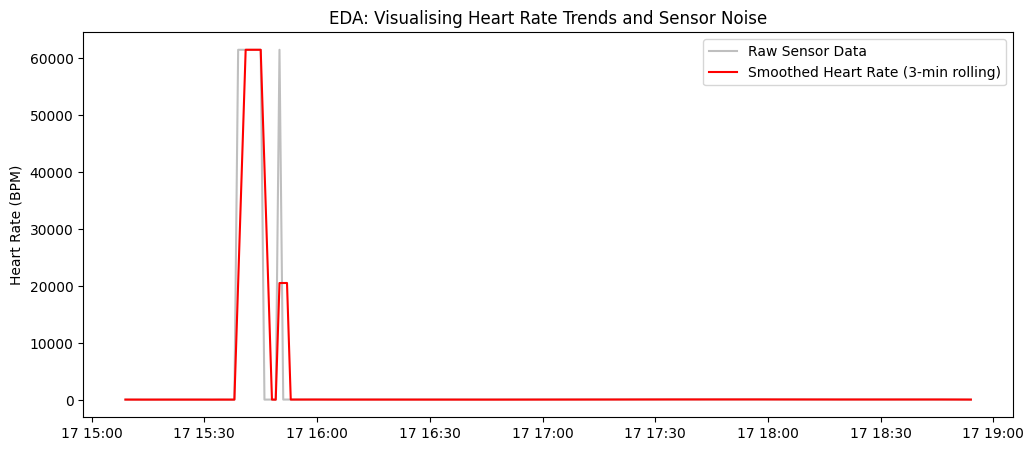

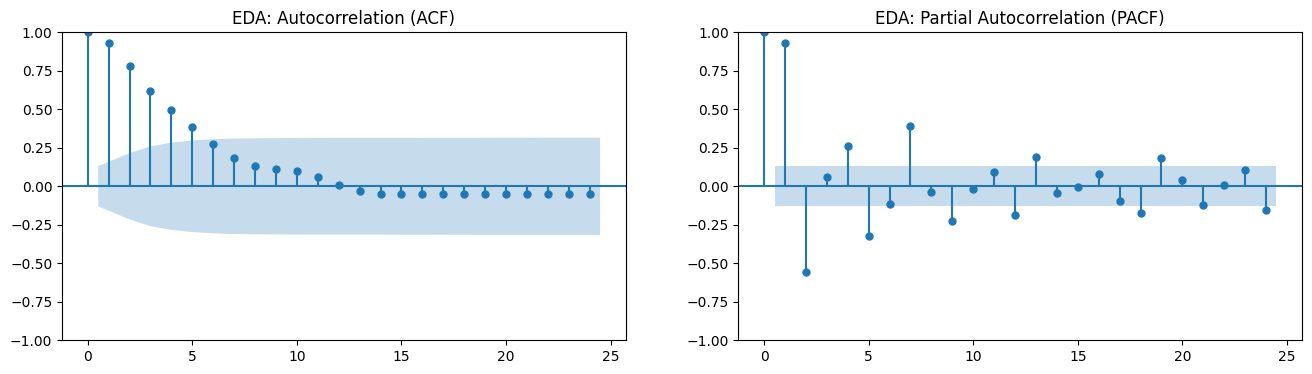

In [4]:
print("\n--- 4. Exploratory Data Analysis (EDA) ---")

# SANITY CHECK: Generate a statistical summary of the data
print("Statistical Summary of the Target Variables:")
display(df[[target_col, 'Smoothed_HR']].describe())

# 1. Visualise the Time Series to explore overarching trends and the impact of smoothing
plt.figure(figsize=(12, 5))
plt.plot(df.index, df[target_col], label='Raw Sensor Data', alpha=0.5, color='gray')
plt.plot(df.index, df['Smoothed_HR'], label='Smoothed Heart Rate (3-min rolling)', color='red')
plt.title('EDA: Visualising Heart Rate Trends and Sensor Noise')
plt.ylabel('Heart Rate (BPM)')
plt.legend()
plt.show()

# 2. Explore Autocorrelation (Hidden repeating patterns) to guide the model parameters
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['Smoothed_HR'], ax=axes[0], title='EDA: Autocorrelation (ACF)')
plot_pacf(df['Smoothed_HR'], ax=axes[1], title='EDA: Partial Autocorrelation (PACF)')
plt.show()

# Feature Selection

--- Augmented Dickey-Fuller (ADF) Test ---
ADF Statistic: -3.0504
p-value: 0.0304


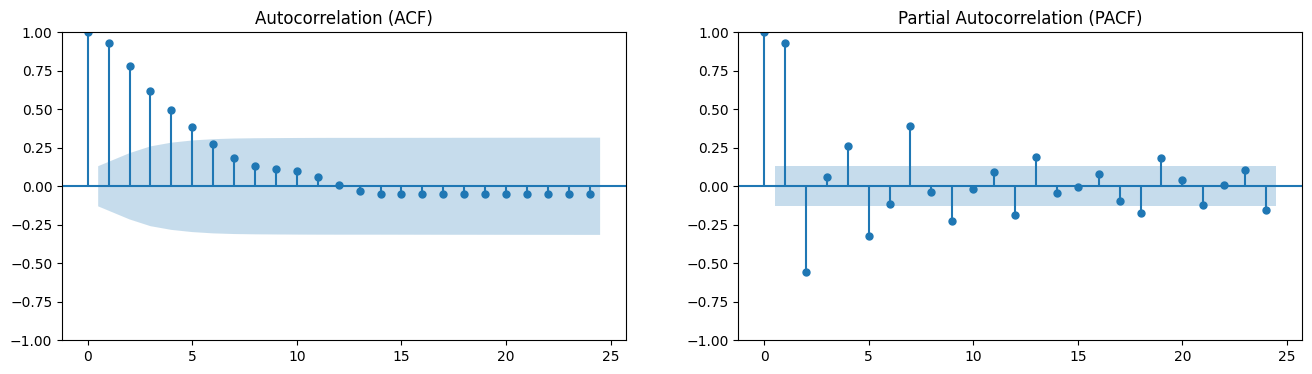

In [5]:
print("--- Augmented Dickey-Fuller (ADF) Test ---")
adf_result = adfuller(df['Smoothed_HR'])
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

# Generate ACF and PACF plots for the blog
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['Smoothed_HR'], ax=axes[0], title='Autocorrelation (ACF)')
plot_pacf(df['Smoothed_HR'], ax=axes[1], title='Partial Autocorrelation (PACF)')
plt.show()

# Chronological Splitting

In [6]:
print("--- 6. Chronological Splitting ---")
# 80% for training, 20% for testing (NO shuffling allowed)
split_point = int(len(df) * 0.8)
train_data = df['Smoothed_HR'].iloc[:split_point]
val_data = df['Smoothed_HR'].iloc[split_point:]

# SANITY CHECK: Verify the timeline is contiguous and did not shuffle
print(f"Total Records: {len(df)}")
print(f"Training Records: {len(train_data)} | Validation Records: {len(val_data)}")
print(f"\nTraining Data ends at:   {train_data.index.max()}")
print(f"Validation Data begins at: {val_data.index.min()}")

print("\nBoundary Audit (Last 3 Train vs First 3 Validation):")
display(pd.DataFrame({'Train_Tail': train_data.tail(3)}))
display(pd.DataFrame({'Val_Head': val_data.head(3)}))

--- 6. Chronological Splitting ---
Total Records: 226
Training Records: 180 | Validation Records: 46

Training Data ends at:   2015-08-17 18:08:00
Validation Data begins at: 2015-08-17 18:09:00

Boundary Audit (Last 3 Train vs First 3 Validation):


,Train_Tail
Timestamp (GMT),
2015-08-17 18:06:00,159.333333
2015-08-17 18:07:00,162.000000
2015-08-17 18:08:00,161.666667


,Val_Head
Timestamp (GMT),
2015-08-17 18:09:00,160.666667
2015-08-17 18:10:00,159.000000
2015-08-17 18:11:00,157.000000


# Modelling

In [7]:
print("Training models...")

# 1. Baseline ARIMA
model_arima = ARIMA(train_data, order=(1, 1, 1))
fitted_arima = model_arima.fit()
pred_arima = fitted_arima.forecast(steps=len(val_data))

# 2. Advanced SARIMA (Assuming 60-min cycles)
model_sarima = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 0, 1, 60))
fitted_sarima = model_sarima.fit(disp=False)
pred_sarima = fitted_sarima.forecast(steps=len(val_data))

# 3. LMA (Local Moving Average implemented via ARIMA configuration)
model_lma = ARIMA(train_data, order=(0, 0, 5))
fitted_lma = model_lma.fit()
pred_lma = fitted_lma.forecast(steps=len(val_data))

print("All 3 models successfully trained and forecasted.")

Training models...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init

All 3 models successfully trained and forecasted.


# Evaluation & Model Comparison

--- Evaluation Results (RMSE) ---
1. ARIMA:  8.54
2. SARIMA: 8.54
3. LMA:    2637.10

WINNER: ARIMA!

--- Sanity Check: Actual vs. Predicted (First 5 Rows of Validation) ---


,Actual_HR,Pred_ARIMA,Pred_SARIMA,Pred_LMA
2015-08-17 18:09:00,160.666667,161.312459,161.312472,414.257849
2015-08-17 18:10:00,159.000000,161.168461,161.168475,1265.579633
2015-08-17 18:11:00,157.000000,161.109922,161.109951,1986.442981
2015-08-17 18:12:00,157.000000,161.086123,161.086153,2568.312747
2015-08-17 18:13:00,154.666667,161.076449,161.076481,2857.989075


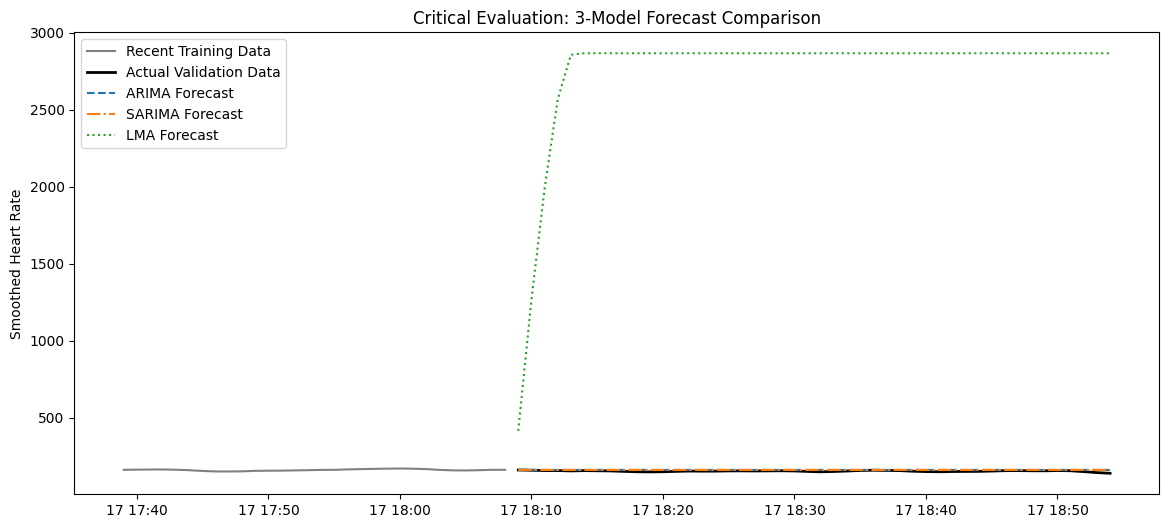

In [8]:
# Calculate Root Mean Squared Error
rmse_arima = np.sqrt(mean_squared_error(val_data, pred_arima))
rmse_sarima = np.sqrt(mean_squared_error(val_data, pred_sarima))
rmse_lma = np.sqrt(mean_squared_error(val_data, pred_lma))

print("--- Evaluation Results (RMSE) ---")
print(f"1. ARIMA:  {rmse_arima:.2f}")
print(f"2. SARIMA: {rmse_sarima:.2f}")
print(f"3. LMA:    {rmse_lma:.2f}")

# Dynamically identify the best model
results = {'ARIMA': rmse_arima, 'SARIMA': rmse_sarima, 'LMA': rmse_lma}
best_name = min(results, key=results.get)
print(f"\nWINNER: {best_name}!")

# SANITY CHECK: View actual vs predicted numbers side-by-side
print("\n--- Sanity Check: Actual vs. Predicted (First 5 Rows of Validation) ---")
comparison_df = pd.DataFrame({
    'Actual_HR': val_data,
    'Pred_ARIMA': pred_arima,
    'Pred_SARIMA': pred_sarima,
    'Pred_LMA': pred_lma
})
display(comparison_df.head(5))

# Visualise the showdown
plt.figure(figsize=(14, 6))
plt.plot(train_data.index[-30:], train_data.iloc[-30:], label='Recent Training Data', color='gray')
plt.plot(val_data.index, val_data, label='Actual Validation Data', color='black', linewidth=2)
plt.plot(val_data.index, pred_arima, label=f'ARIMA Forecast', linestyle='--')
plt.plot(val_data.index, pred_sarima, label=f'SARIMA Forecast', linestyle='-.')
plt.plot(val_data.index, pred_lma, label=f'LMA Forecast', linestyle=':')
plt.title('Critical Evaluation: 3-Model Forecast Comparison')
plt.ylabel('Smoothed Heart Rate')
plt.legend()
plt.show()

# Final Prediction & CSV Export

In [11]:
print(f"Retraining the winning model ({best_name}) on the full dataset...")

# 1. Configure the final model based on the winner of Block 8
if best_name == 'ARIMA':
    final_model = ARIMA(df['Smoothed_HR'], order=(1, 1, 1))
    final_fitted = final_model.fit()
elif best_name == 'SARIMA':
    final_model = SARIMAX(df['Smoothed_HR'], order=(1, 1, 1), seasonal_order=(1, 0, 1, 60))
    final_fitted = final_model.fit(disp=False)
else:
    final_model = ARIMA(df['Smoothed_HR'], order=(0, 0, 5))
    final_fitted = final_model.fit()

# 2. Fit and predict the next 20 minutes into the unknown future
future_20_mins = final_fitted.forecast(steps=20)

# 3. Format the predictions as requested by the assessment brief
submission_df = pd.DataFrame({
    'Minute_Offset': range(1, 21),
    'Predicted_Lifetouch_HR': future_20_mins.values
})

# 4. CRITICAL EVALUATION: View a sample of n=5 results for a sanity check
print("\n--- Sanity Check: Sample of 5 Future Predictions ---")
display(submission_df.sample(5))

# 5. Export to CSV for Moodle submission
submission_df.to_csv('heart_rate_predictions.csv', index=False)
print("\nSuccess: 'heart_rate_predictions.csv' generated.")

Retraining the winning model (ARIMA) on the full dataset...

--- Sanity Check: Sample of 5 Future Predictions ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)


,Minute_Offset,Predicted_Lifetouch_HR
15,16,136.072693
6,7,136.078671
19,20,136.072691
2,3,136.291702
10,11,136.072855



Success: 'heart_rate_predictions.csv' generated.


# Pipeline Flowchart

Success: Multi-colored flowchart generated! Right-click the image below to save it.


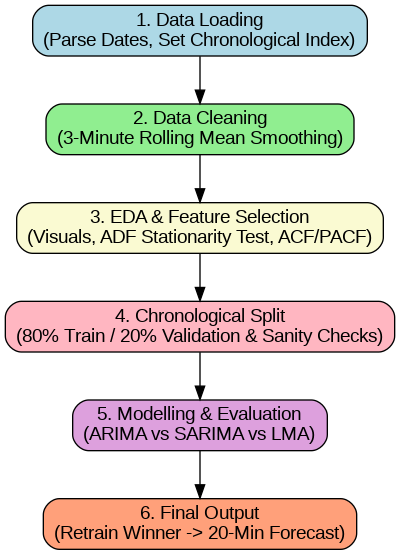

In [12]:
from graphviz import Digraph
from IPython.display import display, Image

# 1. Initialize the flowchart
ts_pipeline = Digraph(comment='Time Series Pipeline')
ts_pipeline.attr(rankdir='TB', size='8,8')

# 2. Set global shape and font, but REMOVE the global color
ts_pipeline.node_attr.update(shape='box', style='rounded,filled', fontname='Helvetica')

# 3. Define each step with a distinct, professional 'fillcolor'
ts_pipeline.node('A', '1. Data Loading\n(Parse Dates, Set Chronological Index)', fillcolor='lightblue')
ts_pipeline.node('B', '2. Data Cleaning\n(3-Minute Rolling Mean Smoothing)', fillcolor='lightgreen')
ts_pipeline.node('C', '3. EDA & Feature Selection\n(Visuals, ADF Stationarity Test, ACF/PACF)', fillcolor='lightgoldenrodyellow')
ts_pipeline.node('D', '4. Chronological Split\n(80% Train / 20% Validation & Sanity Checks)', fillcolor='lightpink')
ts_pipeline.node('E', '5. Modelling & Evaluation\n(ARIMA vs SARIMA vs LMA)', fillcolor='plum')
ts_pipeline.node('F', '6. Final Output\n(Retrain Winner -> 20-Min Forecast)', fillcolor='lightsalmon')

# 4. Connect the arrows
ts_pipeline.edges(['AB', 'BC', 'CD', 'DE', 'EF'])

# 5. Render and display
ts_pipeline.render('ts_pipeline_flowchart', format='png', cleanup=True)
print("Success: Multi-colored flowchart generated! Right-click the image below to save it.")
display(Image(filename='ts_pipeline_flowchart.png'))